In [54]:
import numpy as np

def generate_gbm_path(sigma, dt, n_steps, S0, seed=123):
    z = np.random.RandomState(seed).normal(size = n_steps)
    t = np.linspace(0, n_steps * dt, n_steps+1)
    w = np.concatenate([[0], np.cumsum(np.sqrt(dt) * z)])
    S = S0 * np.exp((-0.5 * sigma ** 2) * t + sigma * w)
    return S
    

def calculate_fee(path, gamma):
    fee = 0
    s = path[0]
    x0 = 1e6
    y0 = 1e6
    L = np.sqrt(x0 * y0)
    for s in path[1:]:
        p0 = y0 / x0
        if s > p0/(1-gamma):
            x1 = L * np.sqrt(1/((1-gamma)*s))
            y1 = L * np.sqrt((1-gamma)*s)
            fee += gamma/(1-gamma) * (y1 - y0)
            x0 = x1
            y0 = y1
        elif s < p0*(1-gamma):
            x1 = L * np.sqrt((1-gamma) / s)
            y1 = L * np.sqrt(s / (1-gamma))
            fee += gamma/(1-gamma) * (x1 - x0) * s
            x0 = x1
            y0 = y1
    return fee

import matplotlib.pyplot as plt
dt = 1 / (365 * 24)
n_steps = 200
sigma = 0.2
gamma = 0.0003
test_case = []
for seed in range(10):
    path1 = generate_gbm_path(sigma=sigma, dt=dt, n_steps=n_steps, S0=1, seed=seed)
    fee = calculate_fee(path1, gamma)
    test_case.append(fee)
    print(fee)

            

47.04553371298106
38.952742346733
45.53145307956984
42.48875067703894
40.857851197219844
42.666377716293276
40.10514454461528
42.704024109300654
48.3492970621129
43.71247337976936


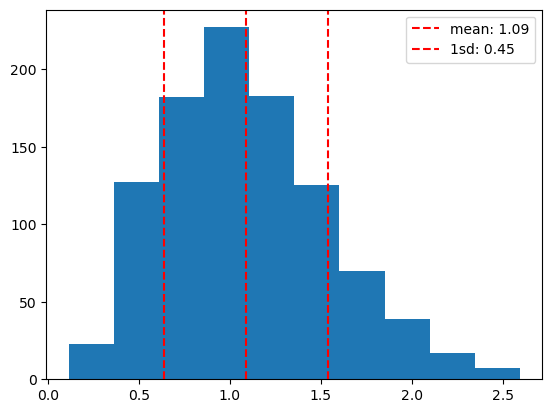

In [73]:
import numpy as np

def generate_gbm_path(sigma, dt, n_steps, S0, seed=123):
    z = np.random.RandomState(seed).normal(size = n_steps)
    t = np.linspace(0, n_steps * dt, n_steps+1)
    w = np.concatenate([[0], np.cumsum(np.sqrt(dt) * z)])
    S = S0 * np.exp((-0.5 * sigma ** 2) * t + sigma * w)
    return S
    

def calculate_fee(path, gamma, N0):
    fee = 0
    s = path[0]
    x0 = 1e6
    y0 = 1e6
    L = np.sqrt(x0 * y0)
    for idx in range(1, len(path)):
        s = path[idx]
        p0 = y0 / x0
        if s > p0/(1-gamma):
            x1 = L * np.sqrt(1/((1-gamma)*s))
            y1 = L * np.sqrt((1-gamma)*s)
            if idx > N0:
                fee += gamma/(1-gamma) * (y1 - y0)
            x0 = x1
            y0 = y1
        elif s < p0*(1-gamma):
            x1 = L * np.sqrt((1-gamma) / s)
            y1 = L * np.sqrt(s / (1-gamma))
            if idx > N0:
                fee += gamma/(1-gamma) * (x1 - x0) * s
            x0 = x1
            y0 = y1
    return fee

import matplotlib.pyplot as plt
dt = 1 / (365 * 24)
n_steps = 200
sigma = 0.2
gamma = 0.0003
fee_case = []
for seed in range(1000):
    path1 = generate_gbm_path(sigma=sigma, dt=dt, n_steps=n_steps, S0=1, seed=seed)
    fee = calculate_fee(path1, gamma, N0=195)
    fee_case.append(fee)
    # print(fee)

# draw distribution of fee_case
# show the mean, and dashed line for 1sd
plt.hist(fee_case, bins=10)
plt.axvline(x=np.mean(fee_case), color='r', linestyle='--')
plt.axvline(x=np.mean(fee_case) + np.std(fee_case), color='r', linestyle='--')
plt.axvline(x=np.mean(fee_case) - np.std(fee_case), color='r', linestyle='--')
# add legend with mean and 1sd with exact values
plt.legend(['mean: {:.2f}'.format(np.mean(fee_case)), '1sd: {:.2f}'.format(np.std(fee_case))])
plt.show()


In [2]:
from theta_class import AMMStationaryDistributionFast
import numpy as np

dt = 1 / (365 * 24)
n_steps = 200
sigma = 0.2
gamma = 0.0003
mu=0
N=500
bins = np.linspace(-1.0, 1.0, N)
bin_centers = 0.5 * (bins[:-1] + bins[1:])
model = AMMStationaryDistributionFast(gamma=gamma, mu=mu, sigma=sigma, dt=dt, bins=bins, bin_centers=bin_centers)
inc_fee = model.collect_results()

print(inc_fee)

0.21545825130857088


In [78]:
import numpy as np
from scipy.stats import norm

dt = 1 / (365 * 24)
n_steps = 1
sigma = 0.2
gamma = 0.0003
L = 1e6
x = 1e6
mu = 0
g = 0.0003

def incoming_fee_vec(theta):
    y   = L**2 / x
    p0  = (y/x) * np.power(1.0 - g, -theta)

    sqrt_dt     = np.sqrt(dt)
    sig_sqrt_dt = sigma * sqrt_dt

    d1 = (np.log((1.0 - g) * y / (p0 * x)) - mu * dt) / sig_sqrt_dt
    d2 = (np.log(y / ((1.0 - g) * x * p0)) - mu * dt) / sig_sqrt_dt

    alpha = L * np.sqrt((1.0 - g) * p0) * np.exp(mu/2 - (sigma**2) * dt / 8.0)

    return (g / (1.0 - g)) * (
        alpha * (norm.cdf(d1) + norm.cdf(-d2))
        - np.exp(mu * dt) * p0 * x * norm.cdf(d1 - sig_sqrt_dt / 2.0)
        - y * norm.cdf(-d2 - sig_sqrt_dt / 2.0)
    )

incoming_fee_vec(0.0)


np.float64(0.21315230617134873)

0.25797316737814563


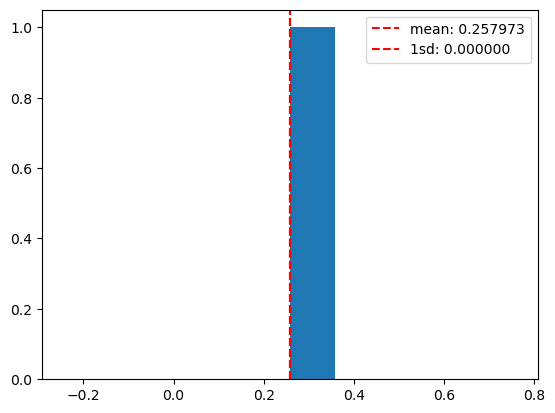

In [ ]:
import numpy as np
from theta_class import AMMStationaryDistributionFast

x0 = 1e6
y0 = 1e6
L = np.sqrt(x0 * y0)
mu=0
N=500
bins = np.linspace(-1.0, 1.0, N)
bin_centers = 0.5 * (bins[:-1] + bins[1:])
model = AMMStationaryDistributionFast(gamma=gamma, mu=mu, sigma=sigma, dt=dt, bins=bins, bin_centers=bin_centers)

def generate_gbm_path(sigma, dt, n_steps, S0, seed=123):
    z = np.random.RandomState(seed).normal(size = n_steps)
    t = np.linspace(0, n_steps * dt, n_steps+1)
    w = np.concatenate([[0], np.cumsum(np.sqrt(dt) * z)])
    S = S0 * np.exp((-0.5 * sigma ** 2) * t + sigma * w)
    return S
    

def calculate_fee(path, gamma, N0):
    fee = 0
    s = path[0]
    x0 = 1e6
    y0 = 1e6
    L = np.sqrt(x0 * y0)
    for idx in range(1, len(path)):
        s = path[idx]
        p0 = y0 / x0
        if s > p0/(1-gamma):
            x1 = L * np.sqrt(1/((1-gamma)*s))
            y1 = L * np.sqrt((1-gamma)*s)
            if idx > N0:
                fee += gamma/(1-gamma) * (y1 - y0)
            x0 = x1
            y0 = y1
        elif s < p0*(1-gamma):
            x1 = L * np.sqrt((1-gamma) / s)
            y1 = L * np.sqrt(s / (1-gamma))
            if idx > N0:
                fee += gamma/(1-gamma) * (x1 - x0) * s
            x0 = x1
            y0 = y1
    return fee

import matplotlib.pyplot as plt
dt = 1 / (365 * 24)
n_steps = 1
sigma = 0.2
gamma = 0.0003
fee_case = []
for seed in range(1):
    theta = model.sample_theta()
    s0 = (y0/x0) * np.power(1.0 - gamma, -theta)
    path1 = generate_gbm_path(sigma=sigma, dt=dt, n_steps=n_steps, S0=s0, seed=)
    fee = calculate_fee(path1, gamma, N0=0)
    fee_case.append(fee)
    print(fee)

# draw distribution of fee_case
# show the mean, and dashed line for 1sd
plt.hist(fee_case, bins=10)
plt.axvline(x=np.mean(fee_case), color='r', linestyle='--')
plt.axvline(x=np.mean(fee_case) + np.std(fee_case), color='r', linestyle='--')
plt.axvline(x=np.mean(fee_case) - np.std(fee_case), color='r', linestyle='--')
# add legend with mean and 1sd with exact values
plt.legend(['mean: {:.6f}'.format(np.mean(fee_case)), '1sd: {:.6f}'.format(np.std(fee_case))])
plt.show()


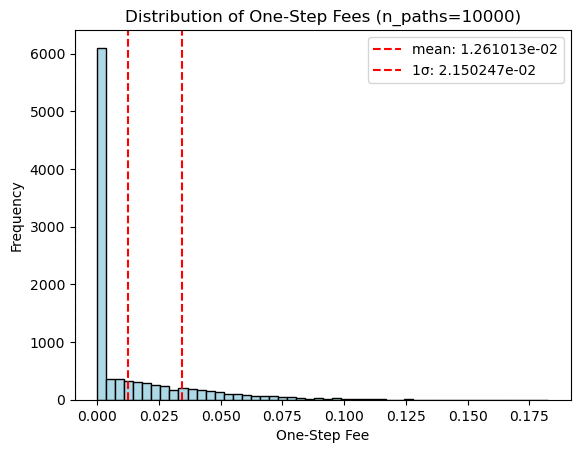

In [83]:
import numpy as np
import matplotlib.pyplot as plt
from theta_class import AMMStationaryDistributionFast

# --- Initialize model ---
x0 = 1e6
y0 = 1e6
L = np.sqrt(x0 * y0)
mu = 0
N = 500
bins = np.linspace(-1.0, 1.0, N)
bin_centers = 0.5 * (bins[:-1] + bins[1:])
dt = 1 / (365 * 24 * 60)
sigma = 0.2
gamma = 0.0003

model = AMMStationaryDistributionFast(gamma=gamma, mu=mu, sigma=sigma, dt=dt, bins=bins, bin_centers=bin_centers)

# --- Parameters ---
n_paths = 10_000
n_steps = 1
rng = np.random.default_rng(123)

# --- 1. Sample theta for all paths ---
theta_list = np.concatenate([model.bin_centers, [-1.0, 1.0]])
pi = model.pi_star / model.pi_star.sum()
theta_samples = rng.choice(theta_list, size=n_paths, p=pi)

# --- 2. Compute s0 for each path ---
s0 = (y0 / x0) * np.power(1.0 - gamma, -theta_samples)

# --- 3. Generate 1-step GBM for all paths ---
z = rng.normal(size=(n_steps, n_paths))
t = np.linspace(0, n_steps * dt, n_steps + 1)[:, None]
w = np.vstack([np.zeros((1, n_paths)), np.cumsum(np.sqrt(dt) * z, axis=0)])
S = s0 * np.exp((-0.5 * sigma**2) * t + sigma * w)  # shape: (n_steps+1, n_paths)

# --- 4. Calculate one-step AMM fees (vectorized form) ---
s1 = S[1, :]
p0 = y0 / x0
L = np.sqrt(x0 * y0)

# Upward arbitrage: external > ask
up_mask = s1 > p0 / (1 - gamma)
fee_up = np.zeros(n_paths)
if np.any(up_mask):
    x1_up = L * np.sqrt(1 / ((1 - gamma) * s1[up_mask]))
    y1_up = L * np.sqrt((1 - gamma) * s1[up_mask])
    fee_up[up_mask] = gamma / (1 - gamma) * (y1_up - y0)

# Downward arbitrage: external < bid
down_mask = s1 < p0 * (1 - gamma)
fee_down = np.zeros(n_paths)
if np.any(down_mask):
    x1_down = L * np.sqrt((1 - gamma) / s1[down_mask])
    y1_down = L * np.sqrt(s1[down_mask] / (1 - gamma))
    fee_down[down_mask] = gamma / (1 - gamma) * (x1_down - x0) * s1[down_mask]

# Combine
fee_case = fee_up + fee_down

# --- 5. Plot results ---
plt.hist(fee_case, bins=50, color='lightblue', edgecolor='k')
mean_fee = np.mean(fee_case)
std_fee = np.std(fee_case)
plt.axvline(mean_fee, color='r', linestyle='--')
plt.axvline(mean_fee + std_fee, color='r', linestyle='--')
plt.axvline(mean_fee - std_fee, color='r', linestyle='--')
plt.legend([
    f"mean: {mean_fee:.6e}",
    f"1σ: {std_fee:.6e}"
])
plt.xlabel("One-Step Fee")
plt.ylabel("Frequency")
plt.title(f"Distribution of One-Step Fees (n_paths={n_paths})")
plt.show()


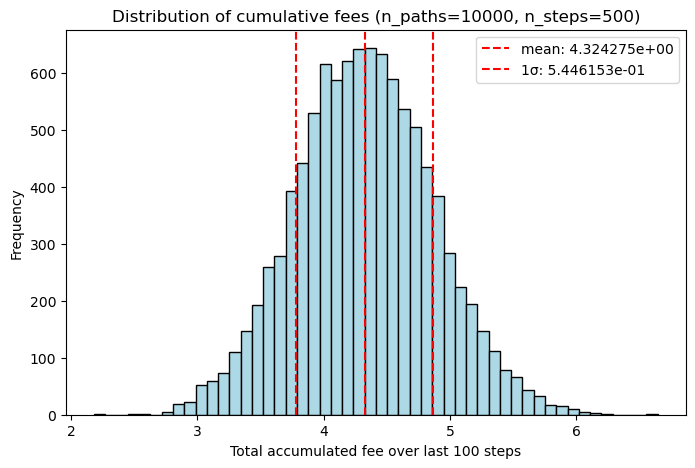

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from theta_class import AMMStationaryDistributionFast

# --- Model parameters ---
x0 = 1e6
y0 = 1e6
import numpy as np
import matplotlib.pyplot as plt
from theta_class import AMMStationaryDistributionFast

# --- Model & sim params ---
x0 = 1e6
y0 = 1e6
L = np.sqrt(x0 * y0)
mu = 0.0
sigma = 1
gamma = 0.0003
dt = 12 / (365 * 24 * 60 * 60)

n_steps = 500         # total steps
N = 100                 # accumulate over last N steps
n_paths = 10_000

# --- Stationary theta model ---
N_bins = 500
bins = np.linspace(-1.0, 1.0, N_bins)
bin_centers = 0.5 * (bins[:-1] + bins[1:])
model = AMMStationaryDistributionFast(gamma=gamma, mu=mu, sigma=sigma, dt=dt,
                                      bins=bins, bin_centers=bin_centers)

rng = np.random.default_rng(123)

# --- Sample theta and compute S0 per path ---
theta_list = np.concatenate([model.bin_centers, [-1.0, 1.0]])
pi = model.pi_star / model.pi_star.sum()
theta_samples = rng.choice(theta_list, size=n_paths, p=pi)
s0 = (y0 / x0) * np.power(1.0 - gamma, -theta_samples)

# --- Generate GBM paths (time x paths) ---
z = rng.normal(size=(n_steps, n_paths))
t = np.linspace(0, n_steps * dt, n_steps + 1)[:, None]
w = np.vstack([np.zeros((1, n_paths)), np.cumsum(np.sqrt(dt) * z, axis=0)])
S = s0[None, :] * np.exp((mu - 0.5 * sigma**2) * t + sigma * w)  # (n_steps+1, n_paths)

# --- Per-path inventories and fee accumulator ---
xt = np.full(n_paths, x0, dtype=float)
yt = np.full(n_paths, y0, dtype=float)
total_fee_lastN = np.zeros(n_paths, dtype=float)

# --- Iterate all steps; only add fees in last N ---
for i in range(1, n_steps + 1):
    s1 = S[i, :]  # external price at step i, per path

    # Current AMM mid price per path
    P_AMM = yt / xt
    bid = P_AMM * (1 - gamma)
    ask = P_AMM / (1 - gamma)

    # Masks
    up_mask = s1 > ask          # external > ask  → users buy Y from AMM
    down_mask = s1 < bid        # external < bid  → users buy X from AMM

    # --- Upward arbitrage updates (vectorized on mask) ---
    if np.any(up_mask):
        # post-trade inventories implied by invariant at execution price
        x_new = L * np.sqrt(1.0 / ((1 - gamma) * s1[up_mask]))
        y_new = L * np.sqrt((1 - gamma) * s1[up_mask])

        # fee (in Y units)
        fee_up = (gamma / (1 - gamma)) * (y_new - yt[up_mask])

        # accumulate only in last N steps
        if i > n_steps - N:
            total_fee_lastN[up_mask] += fee_up

        # update inventories for those paths
        xt[up_mask] = x_new
        yt[up_mask] = y_new

    # --- Downward arbitrage updates (vectorized on mask) ---
    if np.any(down_mask):
        x_new = L * np.sqrt((1 - gamma) / s1[down_mask])
        y_new = L * np.sqrt(s1[down_mask] / (1 - gamma))

        # fee is taken in X, convert to Y-equivalent via s1
        fee_down = (gamma / (1 - gamma)) * (x_new - xt[down_mask]) * s1[down_mask]

        if i > n_steps - N:
            total_fee_lastN[down_mask] += fee_down

        xt[down_mask] = x_new
        yt[down_mask] = y_new

# --- Plot distribution of cumulative fees over last N steps ---
plt.figure(figsize=(8,5))
plt.hist(total_fee_lastN, bins=50, color='lightblue', edgecolor='k')
mean_fee = np.mean(total_fee_lastN)
std_fee = np.std(total_fee_lastN)
plt.axvline(mean_fee, color='r', linestyle='--')
plt.axvline(mean_fee + std_fee, color='r', linestyle='--')
plt.axvline(mean_fee - std_fee, color='r', linestyle='--')
plt.legend([f"mean: {mean_fee:.6e}", f"1σ: {std_fee:.6e}"])
plt.xlabel(f"Total accumulated fee over last {N} steps")
plt.ylabel("Frequency")
plt.title(f"Distribution of cumulative fees (n_paths={n_paths}, n_steps={n_steps})")
plt.show()


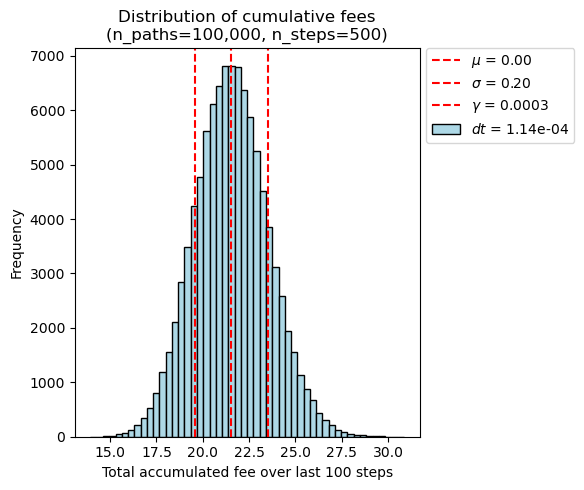

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
from theta_class import AMMStationaryDistributionFast

# --- Parameters ---
x0 = 1e6
y0 = 1e6
L = np.sqrt(x0 * y0)
mu = 0.0
sigma = 0.2
gamma = 0.0003
dt = 1 / (365 * 24)

n_steps = 500          # total simulation steps
N = 100                # accumulation window
n_paths = 100_000      # number of Monte Carlo paths

# --- Stationary theta model ---
N_bins = 500
bins = np.linspace(-1.0, 1.0, N_bins)
bin_centers = 0.5 * (bins[:-1] + bins[1:])
model = AMMStationaryDistributionFast(gamma=gamma, mu=mu, sigma=sigma, dt=dt,
                                      bins=bins, bin_centers=bin_centers)

rng = np.random.default_rng(123)

# --- Sample theta and compute initial price S0 per path ---
theta_list = np.concatenate([model.bin_centers, [-1.0, 1.0]])
pi = model.pi_star / model.pi_star.sum()
theta_samples = rng.choice(theta_list, size=n_paths, p=pi)
s0 = (y0 / x0) * np.power(1.0 - gamma, -theta_samples)

# --- Generate GBM paths (time x paths) ---
z = rng.normal(size=(n_steps, n_paths))
t = np.linspace(0, n_steps * dt, n_steps + 1)[:, None]
w = np.vstack([np.zeros((1, n_paths)), np.cumsum(np.sqrt(dt) * z, axis=0)])
S = s0[None, :] * np.exp((mu - 0.5 * sigma**2) * t + sigma * w)

# --- Initialize inventories and accumulators ---
xt = np.full(n_paths, x0, dtype=float)
yt = np.full(n_paths, y0, dtype=float)
total_fee_lastN = np.zeros(n_paths, dtype=float)

# --- Simulation loop ---
for i in range(1, n_steps + 1):
    s1 = S[i, :]
    P_AMM = yt / xt
    bid = P_AMM * (1 - gamma)
    ask = P_AMM / (1 - gamma)

    up_mask = s1 > ask
    down_mask = s1 < bid

    if np.any(up_mask):
        x_new = L * np.sqrt(1.0 / ((1 - gamma) * s1[up_mask]))
        y_new = L * np.sqrt((1 - gamma) * s1[up_mask])
        fee_up = (gamma / (1 - gamma)) * (y_new - yt[up_mask])
        if i > n_steps - N:
            total_fee_lastN[up_mask] += fee_up
        xt[up_mask], yt[up_mask] = x_new, y_new

    if np.any(down_mask):
        x_new = L * np.sqrt((1 - gamma) / s1[down_mask])
        y_new = L * np.sqrt(s1[down_mask] / (1 - gamma))
        fee_down = (gamma / (1 - gamma)) * (x_new - xt[down_mask]) * s1[down_mask]
        if i > n_steps - N:
            total_fee_lastN[down_mask] += fee_down
        xt[down_mask], yt[down_mask] = x_new, y_new

# --- Plot results ---
plt.figure(figsize=(8, 5))
plt.hist(total_fee_lastN, bins=50, color='lightblue', edgecolor='k')
mean_fee = np.mean(total_fee_lastN)
std_fee = np.std(total_fee_lastN)
plt.axvline(mean_fee, color='r', linestyle='--')
plt.axvline(mean_fee + std_fee, color='r', linestyle='--')
plt.axvline(mean_fee - std_fee, color='r', linestyle='--')

# --- Create legend outside the plot ---
legend_text = [
    f"$\\mu$ = {mu:.2f}",
    f"$\\sigma$ = {sigma:.2f}",
    f"$\\gamma$ = {gamma:.4f}",
    f"$dt$ = {dt:.2e}",
    f"Steps = {n_steps}, Paths = {n_paths:,}",
    f"Mean fee = {mean_fee:.3e}",
    f"Std = {std_fee:.3e}"
]
plt.legend(legend_text, loc='upper left', bbox_to_anchor=(1.02, 1), borderaxespad=0)

plt.xlabel(f"Total accumulated fee over last {N} steps")
plt.ylabel("Frequency")
plt.title(f"Distribution of cumulative fees\n(n_paths={n_paths:,}, n_steps={n_steps})")
plt.tight_layout(rect=[0, 0, 0.75, 1])  # make room for legend on right
plt.show()


In [2]:
from theta_class import AMMStationaryDistributionFast
import numpy as np


L = 1e6
x = 1e6
dt = 1 / (365 * 24)
n_steps = 200
sigma = 0.2
gamma = 0.0003
N = 500
bins = np.linspace(-1.0, 1.0, N)
bin_centers = 0.5 * (bins[:-1] + bins[1:])
model = AMMStationaryDistributionFast(gamma=gamma, mu=0, sigma=sigma, dt=dt, bins=bins, bin_centers=bin_centers)

print(model._expected_incoming_fee_v2(s0=1))

print(model._expected_incoming_fee_vec())


0.215458218410235
0.21545825130857088


In [12]:
import numpy as np
from scipy.stats import lognorm
from scipy.integrate import quad

def expected_total_fee_over_future(model, mu, sigma, dt, start_step, end_step, S0=1.0):
    """
    Computes E[Σ f(S_t)] for t ∈ [start_step, end_step],
    where S_t ~ GBM(S0, mu, sigma).
    """
    total_exp_fee = 0.0
    for step in range(start_step, end_step + 1):
        t = step * dt
        
        # GBM lognormal parameters
        mean_ln = np.log(S0) + (mu - 0.5 * sigma**2) * t
        sd_ln   = sigma * np.sqrt(t)
        
        # Define integrand f(s) * pdf(s)
        def integrand(s):
            return model._expected_incoming_fee_v2(s0=s) * lognorm.pdf(s, s=sd_ln, scale=np.exp(mean_ln))
        
        # Integration range: 5σ band around mean
        low = np.exp(mean_ln - 5 * sd_ln)
        high = np.exp(mean_ln + 5 * sd_ln)
        
        val, _ = quad(integrand, low, high, limit=200, epsabs=1e-8)
        total_exp_fee += val
    
    return total_exp_fee

# Example usage:
mu = 0.0
sigma = 0.2
dt = 1 / (365 * 24)
# n_steps = 200
start_step = 1
end_step = 3

total_fee = expected_total_fee_over_future(model, mu, sigma, dt, start_step, end_step, S0=1.0)
print(f"Expected total fee from step {start_step} to {end_step}: {total_fee:.6e}")


Expected total fee from step 1 to 3: 6.463735e-01
